In [1]:
import sys
sys.path.append('../../src')
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from TRIOMA.tools.Extractors.GasLiquidContactor import GLC, GLC_Gas, Fluid
import TRIOMA.tools.Extractors.extractor as extractor
import numpy as np
import matplotlib.pyplot as plt
import mph

R_const = 8.31
T = 673
R = 0.3
Q_l = 80.0 * 1e-3 / 360
p_in = 1000
c_PbLi = 56182

area = np.pi * R**2
u_l = Q_l / area
kla = 5E-3

PbLi = Fluid(Solubility=1.33E-4 * np.exp(-1350 / R_const / T), MS=False)
c_in = p_in**0.5 * PbLi.Solubility

Z_vec = np.linspace(0.05, 0.7, 5)
Q_gas_vec = np.linspace(6e-3 / 3600, 100 / 3600, 5)
p_in_g_vec = np.linspace(0.0, p_in*0.8, 5)

client = mph.start()
model = client.load('GenericLMGLC.mph')

In [2]:
scatter_mat = np.empty((0, 5))
count = 0
n_total = len(p_in_g_vec) * len(Q_gas_vec) * len(Z_vec)
for p_in_g in p_in_g_vec:
    for Q_gas in Q_gas_vec:
        u_g = extractor.calculate_gas_velocity(G_gas=Q_gas, p_t=1.5E5, T=T, R=R)
        R_g = 2 * u_g / u_l
        for Z in Z_vec:
            NTU = kla * Z / u_l
            count += 1
            print("Iteration", str(count), "of", n_total,
                  "| NTU=", NTU, "R_g=", R_g, "p_in_g=", p_in_g)

            SweepGas = GLC_Gas(G_gas=Q_gas, pg_in=p_in_g, p_tot=1.5E5)
            Melodie = GLC(H=Z, R=R, c_in=c_in, fluid=PbLi, GLC_gas=SweepGas, T=T, G_L=Q_l)
            Melodie.kla = kla
            Melodie.get_c_out()
            eff = Melodie.eff

            model.parameter("H", Melodie.H)
            model.parameter("P", Melodie.GLC_gas.p_tot)
            model.parameter("Ls", Melodie.G_L * c_PbLi)
            model.parameter("Vs", Melodie.GLC_gas.G_gas)
            model.parameter("R", Melodie.R)
            model.parameter("c2_in", Melodie.GLC_gas.pg_in / R_const / Melodie.T)
            model.parameter("Kl_a", Melodie.kla)
            model.parameter("c_in", Melodie.c_in)
            model.parameter("K_S2", PbLi.Solubility)
            model.solve()
            eff_coms = model.evaluate("eff")
            err = abs(eff_coms - eff) / min(eff, eff_coms)

            print("TRIOMA eff is", eff)
            print("Comsol eff is", eff_coms)
            print("err is", err)

            new_row = np.array([NTU, R_g, p_in_g, err, eff])
            scatter_mat = np.vstack((scatter_mat, new_row))  # Append the new row

Iteration 1 of 125 | NTU= 0.3180862561759666 R_g= 0.02366535658511192 p_in_g= 0.0
TRIOMA eff is 0.20130404429522208
Comsol eff is 0.20087910814290585
err is 0.0021153825116245004
Iteration 2 of 125 | NTU= 1.3518665887478578 R_g= 0.02366535658511192 p_in_g= 0.0


c:\Users\Gabriele\OneDrive - Massachusetts Institute of Technology\Desktop\TRIOMA\TRIOMA_Verification\GLC_Verification\../../src\TRIOMA\tools\Extractors\extractor.py:150: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral = integrate.quad(toint, c_out, c_in, points=c_out_max, maxp1=1e3)


TRIOMA eff is 0.4767774718464707
Comsol eff is 0.475144193628045
err is 0.0034374369724577843
Iteration 3 of 125 | NTU= 2.385646921319749 R_g= 0.02366535658511192 p_in_g= 0.0
TRIOMA eff is 0.5905580608209815
Comsol eff is 0.588342666231148
err is 0.003765483479253855
Iteration 4 of 125 | NTU= 3.4194272538916404 R_g= 0.02366535658511192 p_in_g= 0.0
TRIOMA eff is 0.6519363149613551
Comsol eff is 0.649439619277372
err is 0.003844384620022243
Iteration 5 of 125 | NTU= 4.453207586463532 R_g= 0.02366535658511192 p_in_g= 0.0
TRIOMA eff is 0.6895806097748576
Comsol eff is 0.6869357635945429
err is 0.003850208884852559
Iteration 6 of 125 | NTU= 0.3180862561759666 R_g= 98.62340145540519 p_in_g= 0.0
TRIOMA eff is 0.27124787771803516
Comsol eff is 0.2712396700483316
err is 3.025984253000375e-05
Iteration 7 of 125 | NTU= 1.3518665887478578 R_g= 98.62340145540519 p_in_g= 0.0
TRIOMA eff is 0.7370679889319963
Comsol eff is 0.7370399220922299
err is 3.808048780687916e-05
Iteration 8 of 125 | NTU= 2.385

c:\Users\Gabriele\OneDrive - Massachusetts Institute of Technology\Desktop\TRIOMA\TRIOMA_Verification\GLC_Verification\../../src\TRIOMA\tools\Extractors\extractor.py:138: RuntimeWarning: divide by zero encountered in scalar divide
  value = 1 / (c - K_S * ((R_const * T / R_g) * (c - c_out + c_in_gas * R_g)) ** 0.5)


TRIOMA eff is 0.34118459151614255
Comsol eff is 0.34030996455973467
err is 0.0025700891760234174
Iteration 28 of 125 | NTU= 2.385646921319749 R_g= 0.02366535658511192 p_in_g= 200.0
TRIOMA eff is 0.425354897015945
Comsol eff is 0.4242058946868127
err is 0.0027085958576332017
Iteration 29 of 125 | NTU= 3.4194272538916404 R_g= 0.02366535658511192 p_in_g= 200.0
TRIOMA eff is 0.4692122430136423
Comsol eff is 0.46799908062887546
err is 0.0025922324102359943
Iteration 30 of 125 | NTU= 4.453207586463532 R_g= 0.02366535658511192 p_in_g= 200.0
TRIOMA eff is 0.49493719644779766
Comsol eff is 0.49375314990367497
err is 0.0023980536516145325
Iteration 31 of 125 | NTU= 0.3180862561759666 R_g= 98.62340145540519 p_in_g= 200.0
TRIOMA eff is 0.15060832137957336
Comsol eff is 0.1505754859571763
err is 0.0002180661891166601
Iteration 32 of 125 | NTU= 1.3518665887478578 R_g= 98.62340145540519 p_in_g= 200.0


c:\Users\Gabriele\OneDrive - Massachusetts Institute of Technology\Desktop\TRIOMA\TRIOMA_Verification\GLC_Verification\../../src\TRIOMA\tools\Extractors\extractor.py:150: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  integral = integrate.quad(toint, c_out, c_in, points=c_out_max, maxp1=1e3)


TRIOMA eff is 0.4097308506798075
Comsol eff is 0.4096414924698215
err is 0.0002181375950157087
Iteration 33 of 125 | NTU= 2.385646921319749 R_g= 98.62340145540519 p_in_g= 200.0
TRIOMA eff is 0.5018980351023588
Comsol eff is 0.5017887391717544
err is 0.00021781264120191888
Iteration 34 of 125 | NTU= 3.4194272538916404 R_g= 98.62340145540519 p_in_g= 200.0
TRIOMA eff is 0.5346837556697647
Comsol eff is 0.5345671604683514
err is 0.0002181114180510439
Iteration 35 of 125 | NTU= 4.453207586463532 R_g= 98.62340145540519 p_in_g= 200.0
TRIOMA eff is 0.5463466517261909
Comsol eff is 0.5462279575409241
err is 0.00021729789482239004
Iteration 36 of 125 | NTU= 0.3180862561759666 R_g= 197.22313755422522 p_in_g= 200.0
TRIOMA eff is 0.1506102437714948
Comsol eff is 0.15057743310375987
err is 0.00021789897103842893
Iteration 37 of 125 | NTU= 1.3518665887478578 R_g= 197.22313755422522 p_in_g= 200.0
TRIOMA eff is 0.40974000111216324
Comsol eff is 0.4096507596428975
err is 0.00021784768407008204
Iteration

In [3]:
# scatter_mat_file_path = 'scatter_mat_glc.txt'
# np.savetxt(scatter_mat_file_path, scatter_mat, delimiter=',', header='NTU,R_g,p_in_g,err_eff,eff', comments='')

In [4]:
import numpy as np
# scatter_mat_file_path = 'scatter_mat_glc.txt'
# scatter_mat = np.loadtxt(scatter_mat_file_path, delimiter=',', skiprows=1)
import matplotlib.pyplot as plt
from matplotlib import cm

# Do not modify the original data
plot_data = np.asarray(scatter_mat, dtype=float).copy()

# Convert error and efficiency to percent
plot_data[:, 3] *= 100
plot_data[:, 4] *= 100

def _label_axes(ax):
    ax.set_xlabel(r'$R_g = 2u_g/u_l$', fontsize=14, labelpad=12)
    ax.set_ylabel(r'$NTU = k_l a \cdot Z / u_l$', fontsize=14, labelpad=12)
    ax.set_zlabel(r'$p_{in,g}$ (Pa)', fontsize=14, labelpad=15)

C:\Users\Gabriele\AppData\Local\Temp\ipykernel_15316\3050966558.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


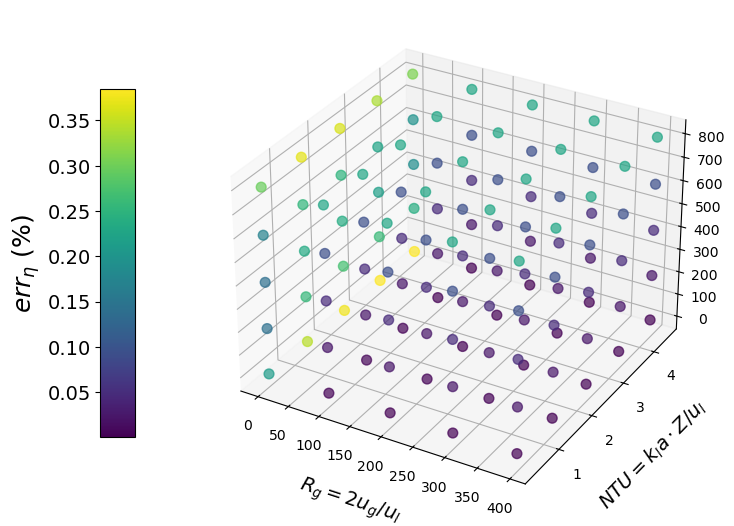

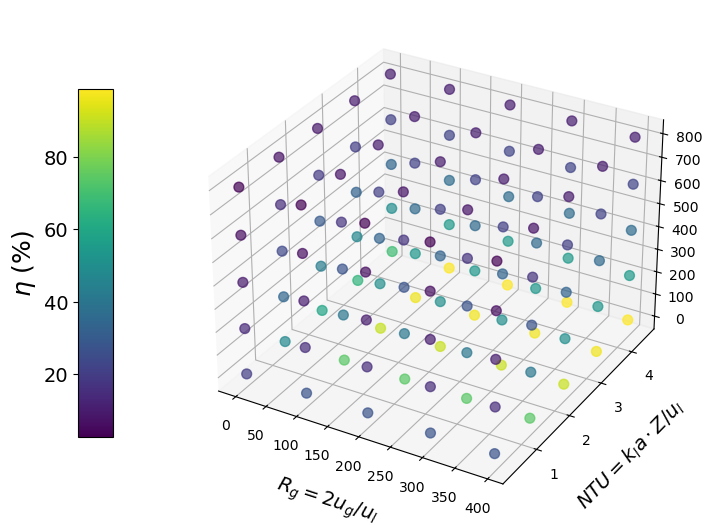

In [5]:
cmap = cm.get_cmap('viridis')
norm1 = plt.Normalize(vmin=abs(plot_data[:, 3]).min(), vmax=abs(plot_data[:, 3]).max())
norm2 = plt.Normalize(vmin=abs(plot_data[:, 4]).min(), vmax=abs(plot_data[:, 4]).max())
colors1 = np.array([
    (1, 0, 0, 1) if value > 5 else cmap(norm1(value))  # (1, 0, 0, 1) is red in RGBA
    for value in abs(plot_data[:, 3])
])
colors2 = np.array([cmap(norm2(value)) for value in abs(plot_data[:, 4])])

# Relative error
fig1 = plt.figure(figsize=(9, 8))
ax1 = fig1.add_subplot(projection='3d')
sc1 = ax1.scatter(plot_data[:, 1], plot_data[:, 0], plot_data[:, 2], c=colors1, s=50, alpha=0.7)
cbar1 = fig1.colorbar(cm.ScalarMappable(norm=norm1, cmap=cmap), ax=ax1, shrink=0.5, aspect=10, location='left')
cbar1.set_label(r'$err_{\eta}$ (%)', fontsize=18)
cbar1.ax.tick_params(labelsize=14)
_label_axes(ax1)
# NOTE: bbox_inches='tight' clips mplot3d z-labels (matplotlib cannot compute a
# correct tight bbox for 3D axis labels), so reserve margin manually instead.
fig1.subplots_adjust(left=0.05, right=0.80, bottom=0.08, top=0.95)
plt.savefig('lm_GLC_verification_error.png', dpi=300)
plt.show()

# Efficiency
fig2 = plt.figure(figsize=(9, 8))
ax2 = fig2.add_subplot(projection='3d')
sc2 = ax2.scatter(plot_data[:, 1], plot_data[:, 0], plot_data[:, 2], c=colors2, s=50, alpha=0.7)
cbar2 = fig2.colorbar(cm.ScalarMappable(norm=norm2, cmap=cmap), ax=ax2, shrink=0.5, aspect=10, location='left')
cbar2.set_label(r'$\eta$ (%)', fontsize=18)
cbar2.ax.tick_params(labelsize=14)
_label_axes(ax2)
fig2.subplots_adjust(left=0.05, right=0.80, bottom=0.08, top=0.95)
plt.savefig('lm_GLC_verification_efficiency.png', dpi=300)
plt.show()